In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/amritachatterjee09/lead-scoring-dataset/Lead Scoring.csv
/kaggle/input/datasets/amritachatterjee09/lead-scoring-dataset/Leads Data Dictionary.xlsx


In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [15]:
df = pd.read_csv("/kaggle/input/datasets/amritachatterjee09/lead-scoring-dataset/Lead Scoring.csv")

In [16]:
# Remove ID columns
df.drop(['Prospect ID','Lead Number'],axis=1,inplace=True)

# Remove constant columns
constant_cols=[col for col in df.columns if df[col].nunique()==1]
df.drop(columns=constant_cols,inplace=True)

# Drop columns having >40% missing values
missing_percent=df.isnull().mean()*100
drop_cols=missing_percent[missing_percent>40].index
df.drop(columns=drop_cols,inplace=True)

In [17]:
(df == 'Select').sum().sort_values(ascending=False)

How did you hear about X Education               5043
Lead Profile                                     4146
City                                             2249
Specialization                                   1942
Converted                                           0
Lead Source                                         0
Do Not Email                                        0
Do Not Call                                         0
Lead Origin                                         0
Last Activity                                       0
Page Views Per Visit                                0
Total Time Spent on Website                         0
TotalVisits                                         0
What matters most to you in choosing a course       0
Search                                              0
Country                                             0
What is your current occupation                     0
X Education Forums                                  0
Newspaper Article           

In [18]:
df.replace('Select', np.nan, inplace=True)

In [19]:
(df == 'Select').sum().sum()

np.int64(0)

In [20]:
round(df.isnull().mean()*100,2).sort_values(ascending=False)

How did you hear about X Education               78.46
Lead Profile                                     74.19
City                                             39.71
Specialization                                   36.58
Tags                                             36.29
What matters most to you in choosing a course    29.32
What is your current occupation                  29.11
Country                                          26.63
Page Views Per Visit                              1.48
TotalVisits                                       1.48
Last Activity                                     1.11
Lead Source                                       0.39
Total Time Spent on Website                       0.00
Lead Origin                                       0.00
Do Not Email                                      0.00
Do Not Call                                       0.00
Converted                                         0.00
X Education Forums                                0.00
Newspaper 

In [21]:
cat_cols=df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [22]:
num_cols=df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [23]:
df.isnull().sum().sum()

np.int64(0)

In [24]:
for col in df.columns:
    if df[col].dtype=='object':
        print(col,df[col].unique()[:5])

Lead Origin ['API' 'Landing Page Submission' 'Lead Add Form' 'Lead Import'
 'Quick Add Form']
Lead Source ['Olark Chat' 'Organic Search' 'Direct Traffic' 'Google' 'Referral Sites']
Do Not Email ['No' 'Yes']
Do Not Call ['No' 'Yes']
Last Activity ['Page Visited on Website' 'Email Opened' 'Unreachable'
 'Converted to Lead' 'Olark Chat Conversation']
Country ['India' 'Russia' 'Kuwait' 'Oman' 'United Arab Emirates']
Specialization ['Finance Management' 'Business Administration' 'Media and Advertising'
 'Supply Chain Management' 'IT Projects Management']
How did you hear about X Education ['Online Search' 'Word Of Mouth' 'Other' 'Multiple Sources'
 'Advertisements']
What is your current occupation ['Unemployed' 'Student' 'Working Professional' 'Businessman' 'Other']
What matters most to you in choosing a course ['Better Career Prospects' 'Flexibility & Convenience' 'Other']
Search ['No' 'Yes']
Newspaper Article ['No' 'Yes']
X Education Forums ['No' 'Yes']
Newspaper ['No' 'Yes']
Digital Adve

In [25]:
yes_no_cols=[
'Do Not Email',
'Do Not Call',
'Search',
'Newspaper Article',
'X Education Forums',
'Newspaper',
'Digital Advertisement',
'Through Recommendations',
'A free copy of Mastering The Interview'
]

In [26]:
for col in yes_no_cols:
    df[col]=df[col].map({'Yes':1,'No':0})

In [27]:
df=pd.get_dummies(df,drop_first=True)

In [28]:
X=df.drop('Converted',axis=1)

y=df['Converted']

In [29]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.30,
random_state=42,
stratify=y
)

In [30]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

In [31]:
print(X_train.shape)
print(X_test.shape)

(6468, 170)
(2772, 170)


In [32]:
import joblib

joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [33]:
import joblib

joblib.dump(X_train, "X_train.pkl")
joblib.dump(X_test, "X_test.pkl")
joblib.dump(y_train, "y_train.pkl")
joblib.dump(y_test, "y_test.pkl")

['y_test.pkl']

In [34]:
import os

print(os.listdir("/kaggle/working"))

['scaler.pkl', 'X_train.pkl', 'y_test.pkl', 'y_train.pkl', 'X_test.pkl', '.virtual_documents']


# P4 - Model Building

In [35]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [36]:
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:,1]

In [37]:
from sklearn.metrics import accuracy_score,classification_report

print("Accuracy:",accuracy_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy: 0.8953823953823954
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1704
           1       0.88      0.85      0.86      1068

    accuracy                           0.90      2772
   macro avg       0.89      0.89      0.89      2772
weighted avg       0.89      0.90      0.90      2772



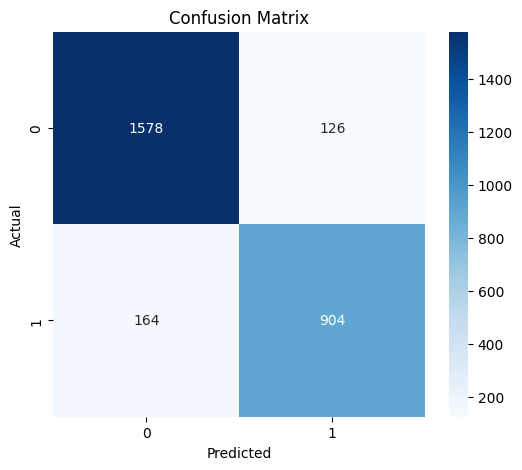

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [39]:
from sklearn.metrics import roc_auc_score

print("ROC-AUC Score:",roc_auc_score(y_test,y_prob))

ROC-AUC Score: 0.9502605128272757


# P5 - Model Comparison & Hyperparameter Tuning

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.8636363636363636


In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8914141414141414


In [42]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.895382
2,Random Forest,0.891414
1,Decision Tree,0.863636


In [43]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
3,Total Time Spent on Website,0.180526
139,Tags_Will revert after reading the email,0.075473
166,Last Notable Activity_SMS Sent,0.062637
134,Tags_Ringing,0.053960
47,Last Activity_SMS Sent,0.043399
122,Tags_Closed by Horizzon,0.041295
2,TotalVisits,0.040518
4,Page Views Per Visit,0.039523
13,Lead Origin_Lead Add Form,0.036652
118,What is your current occupation_Working Profes...,0.029710


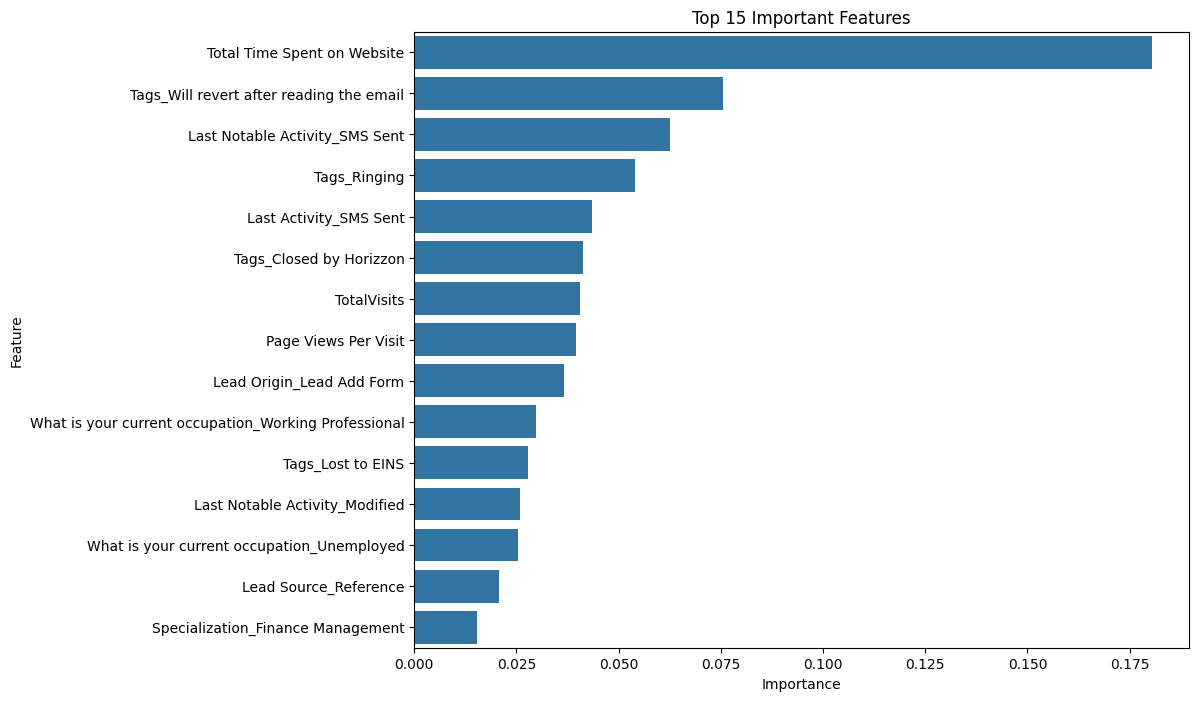

In [44]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.show()

In [45]:
import joblib

joblib.dump(rf, "lead_scoring_model.pkl")

['lead_scoring_model.pkl']

## P6


In [46]:
# Predict Probability
lead_probability = rf.predict_proba(X_test)[:,1]

# Convert Probability to Lead Score
lead_score = (lead_probability * 100).round(2)

lead_score[:10]

array([ 29.6 ,  83.  ,  14.  ,   1.5 ,  24.5 , 100.  ,  94.  ,  12.5 ,
        75.  ,  21.21])

In [47]:
results = pd.DataFrame({
    "Actual": y_test,
    "Prediction": rf_pred,
    "Lead Score": lead_score
})

results.head(10)

,Actual,Prediction,Lead Score
8305,0,0,29.60
1591,1,1,83.00
8604,0,0,14.00
1333,0,0,1.50
4260,0,0,24.50
2357,1,1,100.00
1900,1,1,94.00
9077,0,0,12.50
6302,1,1,75.00
8158,1,0,21.21


In [48]:
def lead_category(score):
    if score >= 80:
        return "Hot Lead"
    elif score >= 60:
        return "Warm Lead"
    else:
        return "Cold Lead"

results["Lead Category"] = results["Lead Score"].apply(lead_category)

results.head(10)

,Actual,Prediction,Lead Score,Lead Category
8305,0,0,29.60,Cold Lead
1591,1,1,83.00,Hot Lead
8604,0,0,14.00,Cold Lead
1333,0,0,1.50,Cold Lead
4260,0,0,24.50,Cold Lead
2357,1,1,100.00,Hot Lead
1900,1,1,94.00,Hot Lead
9077,0,0,12.50,Cold Lead
6302,1,1,75.00,Warm Lead
8158,1,0,21.21,Cold Lead


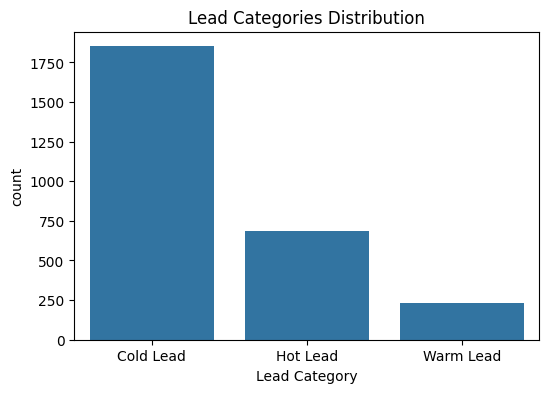

In [49]:
plt.figure(figsize=(6,4))

sns.countplot(data=results, x="Lead Category")

plt.title("Lead Categories Distribution")
plt.show()

In [50]:
results.to_csv("lead_scores.csv", index=False)

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [53]:
print("="*50)
print("Best Model : Random Forest")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision :", precision_score(y_test, rf_pred))
print("Recall :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC :", roc_auc_score(y_test, lead_probability))
print("="*50)

Best Model : Random Forest
Accuracy : 0.8914141414141414
Precision : 0.8800792864222002
Recall : 0.8314606741573034
F1 Score : 0.8550794415021666
ROC-AUC : 0.9503083183872272


In [54]:
import joblib

joblib.dump(rf, "lead_scoring_model.pkl")
print("Model Saved Successfully!")

Model Saved Successfully!


In [55]:
results.to_csv("lead_scores.csv", index=False)
print("Lead Scores Saved Successfully!")

Lead Scores Saved Successfully!


In [57]:
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

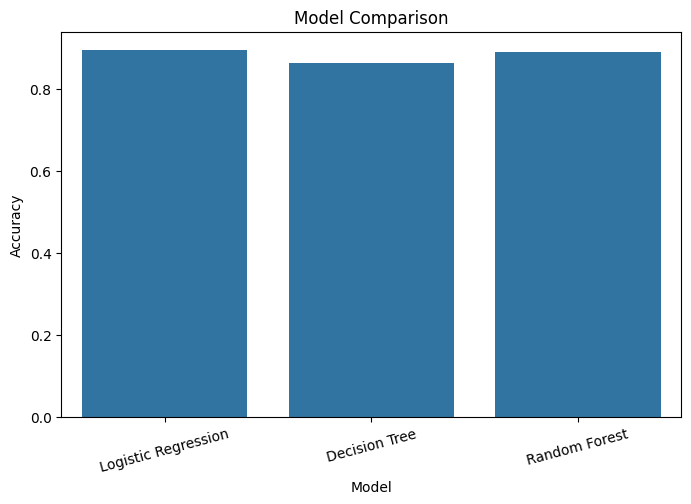

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(data=results_df, x="Model", y="Accuracy")

plt.title("Model Comparison")

plt.xticks(rotation=15)

plt.show()

In [59]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
3,Total Time Spent on Website,0.180526
139,Tags_Will revert after reading the email,0.075473
166,Last Notable Activity_SMS Sent,0.062637
134,Tags_Ringing,0.053960
47,Last Activity_SMS Sent,0.043399
122,Tags_Closed by Horizzon,0.041295
2,TotalVisits,0.040518
4,Page Views Per Visit,0.039523
13,Lead Origin_Lead Add Form,0.036652
118,What is your current occupation_Working Profes...,0.029710


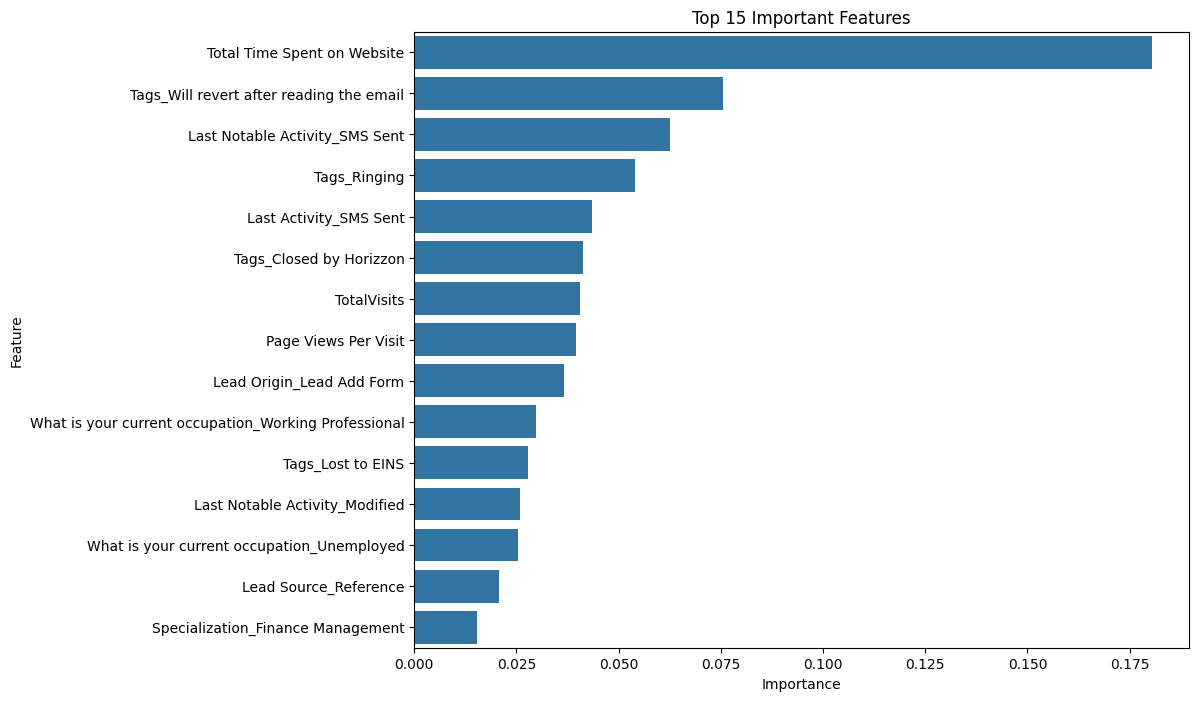

In [60]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

## Business Recommendations

• Focus immediately on Hot Leads (Lead Score ≥ 80).

• Nurture Warm Leads through email campaigns.

• Automate follow-up for Cold Leads.

• Allocate more sales resources to high-scoring leads.

• Continuously retrain the model with new lead data.

### Future Scope

• Streamlit Deployment

• CRM Integration

• Real-time Lead Scoring

• XGBoost Implementation

• Auto Retraining

• Dashboard Creation